Source Data: https://www.kaggle.com/datasets/asiedubrempong/minerals-identification-dataset

# *1. Import semua modul Library yang dibutuhkan*

In [21]:
from natsort import natsorted
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
sns.set_theme ( style = "darkgrid")
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'browser'

import matplotlib.image as mpimg
import random
from skimage.io import imread
import cv2
import xgboost
from PIL.Image import open

from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import average_precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.metrics import roc_curve
from sklearn.model_selection import cross_val_score , train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import BaggingClassifier
from sklearn.multiclass import OneVsRestClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Input
from keras.layers import InputLayer, MaxPooling2D, Flatten, Dense, Conv2D, Dropout
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions, ResNet50
from tensorflow.keras.optimizers import Adam, SGD
from keras.applications import MobileNetV2

# *2. Import Dataset*

In [22]:
import os
import cv2
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Tentukan Path Utama (sesuaikan dengan lokasi folder mineral kamu di Drive)
# Berdasarkan gambar, sepertinya folder-folder mineral ada di dalam satu direktori induk
base_path = '/content/drive/MyDrive/Colab Notebooks/Datasets/minet'
kategori_mineral = ['malachite', 'muscovite', 'pyrite', 'quartz']

# List untuk menampung data gambar dan labelnya
dataset_gambar = []
label_mineral = []

# 3. Proses Loading Dataset
for kategori in kategori_mineral:
    # Gabungkan path utama dengan nama folder kategori
    folder_path = os.path.join(base_path, kategori)

    print(f"\n--- Memproses Folder: {kategori} ---")

    # Cek apakah folder tersebut ada
    if os.path.exists(folder_path):
        # List semua file dalam folder kategori
        for filename in os.listdir(folder_path):
            # Filter hanya file gambar
            if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
                # Membaca gambar menggunakan OpenCV
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path)

                if img is not None:
                    dataset_gambar.append(img)
                    label_mineral.append(kategori)
                    # Sesuai referensi kamu, kita cetak nama filenya
                    print(f"Berhasil load: {filename}")
                else:
                    print(f"Gagal membaca: {filename}")
    else:
        print(f"Peringatan: Folder {kategori} tidak ditemukan di {folder_path}")

# 4. Ringkasan Data
print("\n=== Ringkasan Dataset ===")
print(f"Total gambar terkumpul: {len(dataset_gambar)}")
print(f"Total label terkumpul: {len(label_mineral)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

--- Memproses Folder: malachite ---
Berhasil load: 0006.jpg
Berhasil load: 0009.jpg
Berhasil load: 0002.jpg
Berhasil load: 0018.jpg
Berhasil load: 0013.jpg
Berhasil load: 0026.jpg
Berhasil load: 0014.jpg
Berhasil load: 0005.jpg
Berhasil load: 0052.jpg
Berhasil load: 0047.jpg
Berhasil load: 0034.jpg
Berhasil load: 0030.jpg
Berhasil load: 0023.jpg
Berhasil load: 0028.jpg
Berhasil load: 0024.jpg
Berhasil load: 0056.jpg
Berhasil load: 0048.jpg
Berhasil load: 0021.jpg
Berhasil load: 0001.jpg
Berhasil load: 0019.jpg
Berhasil load: 0017.jpg
Berhasil load: 0033.jpg
Berhasil load: 0032.jpg
Berhasil load: 0020.jpg
Berhasil load: 0029.jpg
Berhasil load: 0011.jpg
Berhasil load: 0054.jpg
Berhasil load: 0022.jpg
Berhasil load: 0040.jpg
Berhasil load: 0049.jpg
Berhasil load: 0008.jpg
Berhasil load: 0046.jpg
Berhasil load: 0043.jpg
Berhasil load: 0004.jpg
Berhasil load: 005

# *3. Data Pre-processing*

In [23]:
import numpy as np
import cv2
import pandas as pd
from google.colab import files

X_simple = []
y_labels = []

print("--- Memulai Ekstraksi Fitur Sederhana (Fix Version) ---")

for i in range(len(dataset_gambar)):
    img = dataset_gambar[i]
    label = label_mineral[i]

    try:
        # --- 1. FITUR WARNA (Mean & Std Dev) ---
        # cv2.meanStdDev mengembalikan (mean, stddev) dalam bentuk array
        means, stds = cv2.meanStdDev(img)

        # Kita ratakan (flatten) lalu ambil 3 nilai pertama (B, G, R)
        mean_b, mean_g, mean_r = means.flatten()[:3]
        std_b, std_g, std_r = stds.flatten()[:3]

        # --- 2. FITUR BENTUK (Geometri) ---
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        # Gunakan Otsu Thresholding untuk membuat siluet mineral
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Default nilai jika kontur tidak ditemukan
        area = perimeter = compactness = aspect_ratio = solidity = 0

        if contours:
            cnt = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(cnt)
            perimeter = cv2.arcLength(cnt, True)

            if perimeter > 0:
                # Compactness: Seberapa bulat objeknya
                compactness = (4 * np.pi * area) / (perimeter**2)

            # Aspect Ratio: Perbandingan Lebar vs Tinggi
            x, y, w, h = cv2.boundingRect(cnt)
            if h > 0:
                aspect_ratio = float(w)/h

            # Solidity: Kepadatan bentuk
            hull = cv2.convexHull(cnt)
            hull_area = cv2.contourArea(hull)
            if hull_area > 0:
                solidity = float(area)/hull_area

        # --- 3. GABUNGKAN FITUR ---
        features = [
            mean_r, mean_g, mean_b,
            std_r, std_g, std_b,
            area, perimeter, compactness, aspect_ratio, solidity,
            np.std(gray) # Indikator kekasaran tekstur sederhana
        ]

        X_simple.append(features)
        y_labels.append(label)

    except Exception as e:
        # Jika satu gambar error, kita lewati dan lanjut ke gambar berikutnya
        print(f"Error pada data ke-{i}: {e}")

# 4. Simpan ke CSV
columns = [
    'mean_red', 'mean_green', 'mean_blue',
    'std_red', 'std_green', 'std_blue',
    'area', 'perimeter', 'compactness', 'aspect_ratio', 'solidity',
    'texture_roughness'
]

df_simple = pd.DataFrame(X_simple, columns=columns)
df_simple['label'] = y_labels # Tambahkan label di kolom terakhir

print(f"\nSelesai! Berhasil mengekstrak {len(df_simple)} data.")

--- Memulai Ekstraksi Fitur Sederhana (Fix Version) ---

Selesai! Berhasil mengekstrak 551 data.






# *4. Penskalaan Data*

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Pisahkan Fitur (X) dan Label (y)
# Kita ambil semua kolom kecuali kolom 'label'
X = df_simple.drop('label', axis=1)
y = df_simple['label']

# 2. Encode Label (Mengubah teks 'malachite', 'pyrite' dll menjadi angka 0, 1, 2, 3)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Mapping Label: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 3. Bagi data menjadi Training dan Testing (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Penskalaan Data (StandardScaler)
scaler = StandardScaler()

# Penting: Fit scaler HANYA pada data train untuk menghindari 'data leakage'
X_train_scaled = scaler.fit_transform(X_train)

# Gunakan parameter yang sama untuk mentransformasi data test
X_test_scaled = scaler.transform(X_test)

print("\n--- Penskalaan Selesai ---")
print(f"Data Train: {X_train_scaled.shape}")
print(f"Data Test: {X_test_scaled.shape}")
print(f"Contoh data setelah di-scaling (5 kolom pertama):\n{X_train_scaled[0][:5]}")

Mapping Label: {'malachite': np.int64(0), 'muscovite': np.int64(1), 'pyrite': np.int64(2), 'quartz': np.int64(3)}

--- Penskalaan Selesai ---
Data Train: (440, 12)
Data Test: (111, 12)
Contoh data setelah di-scaling (5 kolom pertama):
[-0.85644854 -1.13796285 -0.93350634 -0.12741399 -0.10006193]


# *5. Menampilkan Distribusi Variabel Target (Class)*

/tmp/ipykernel_710/1861953861.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




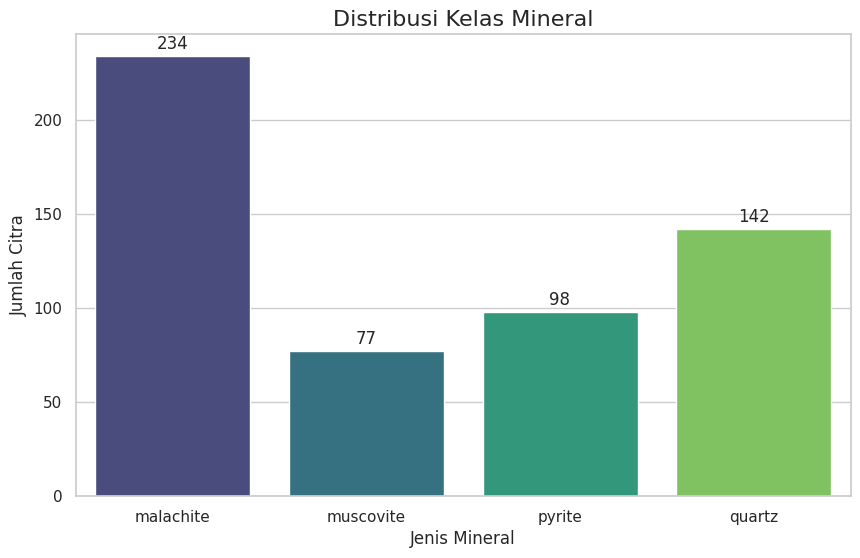


--- Persentase Data ---
label
malachite    42.468240
quartz       25.771325
pyrite       17.785844
muscovite    13.974592
Name: proportion, dtype: float64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengatur tema visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 2. Membuat Countplot (Grafik Batang Jumlah)
# Menggunakan kolom 'label' dari DataFrame df_simple yang kita buat tadi
ax = sns.countplot(x='label', data=df_simple, palette='viridis')

# 3. Menambahkan Judul dan Label
plt.title('Distribusi Kelas Mineral', fontsize=16)
plt.xlabel('Jenis Mineral', fontsize=12)
plt.ylabel('Jumlah Citra', fontsize=12)

# 4. Menambahkan angka di atas setiap batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points')

plt.show()

# 5. Menampilkan persentase (opsional)
print("\n--- Persentase Data ---")
print(df_simple['label'].value_counts(normalize=True) * 100)

# *6. Menampilkan Distribusi Mean RGB*

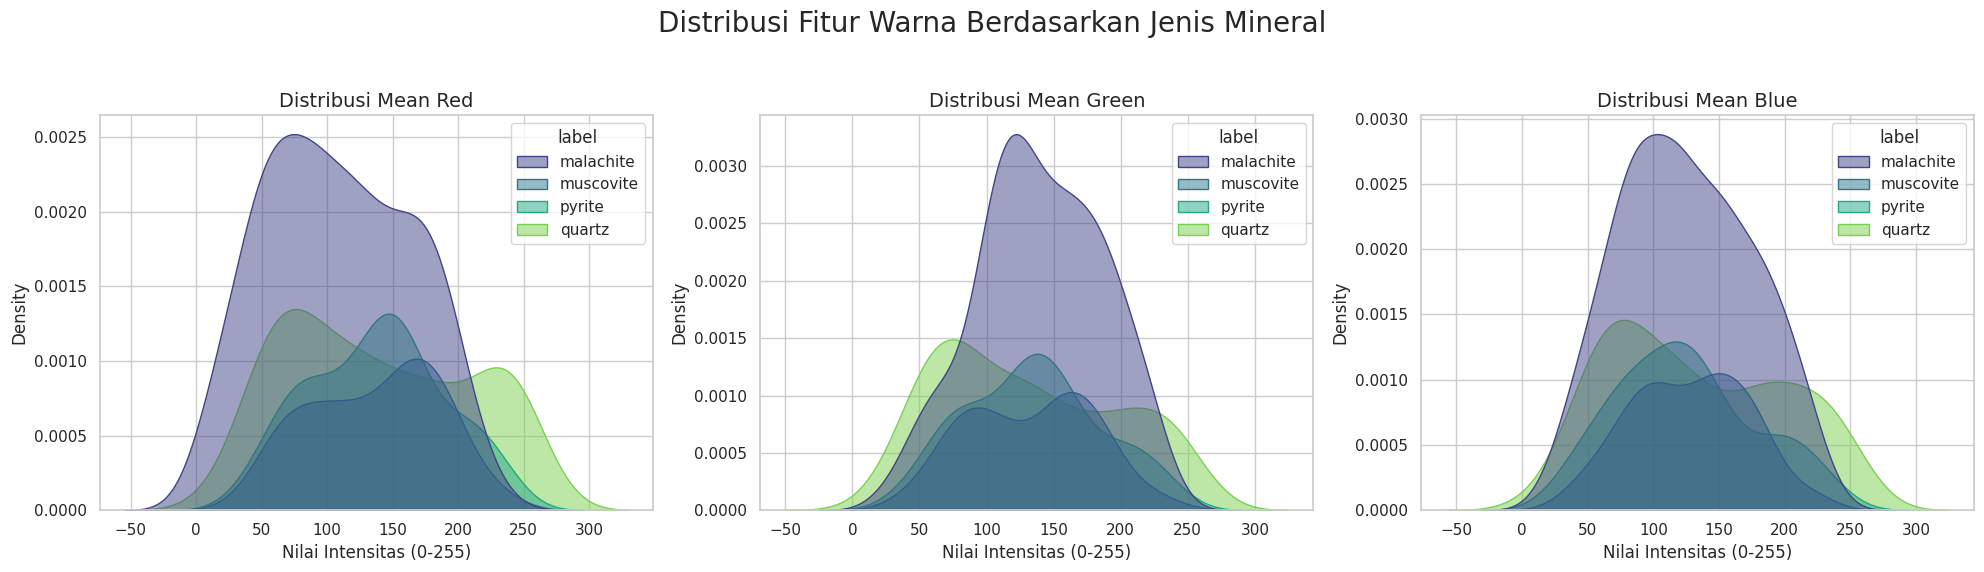

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengatur layout subplot (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distribusi Fitur Warna Berdasarkan Jenis Mineral', fontsize=20)

colors = ['mean_red', 'mean_green', 'mean_blue']
palette = ['#e74c3c', '#2ecc71', '#3498db'] # Merah, Hijau, Biru untuk estetika plot

# 2. Looping untuk membuat grafik tiap fitur warna
for i, feature in enumerate(colors):
    sns.kdeplot(
        data=df_simple,
        x=feature,
        hue='label',
        fill=True,
        ax=axes[i],
        palette='viridis',
        alpha=0.5
    )
    axes[i].set_title(f'Distribusi {feature.replace("_", " ").title()}', fontsize=14)
    axes[i].set_xlabel('Nilai Intensitas (0-255)')
    axes[i].set_ylabel('Density')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# *7. Implementasi Model SVM*

In [27]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Membangun Model SVM
# C: Regularisasi (semakin besar, model semakin berusaha mengklasifikasikan data train dengan benar)
# gamma: Menentukan seberapa jauh pengaruh satu contoh pelatihan mencapai
model_svm = SVC(kernel='rbf', C=10.0, gamma='scale', random_state=42)

# 2. Melatih Model (Training)
print("--- Sedang Melatih Model SVM... ---")
model_svm.fit(X_train_scaled, y_train)
print("Pelatihan Selesai!\n")

# 3. Melakukan Prediksi pada Data Test
y_pred = model_svm.predict(X_test_scaled)

# 4. Evaluasi Hasil
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n=== Laporan Klasifikasi ===")
# target_names mengambil nama mineral asli dari LabelEncoder yang kita buat tadi
print(classification_report(y_test, y_pred, target_names=le.classes_))

--- Sedang Melatih Model SVM... ---
Pelatihan Selesai!

Akurasi Model: 77.48%

=== Laporan Klasifikasi ===
              precision    recall  f1-score   support

   malachite       0.92      0.89      0.91        55
   muscovite       0.50      0.29      0.36        14
      pyrite       0.52      0.61      0.56        18
      quartz       0.76      0.92      0.83        24

    accuracy                           0.77       111
   macro avg       0.68      0.68      0.67       111
weighted avg       0.77      0.77      0.77       111



# *8. KDE Plot*

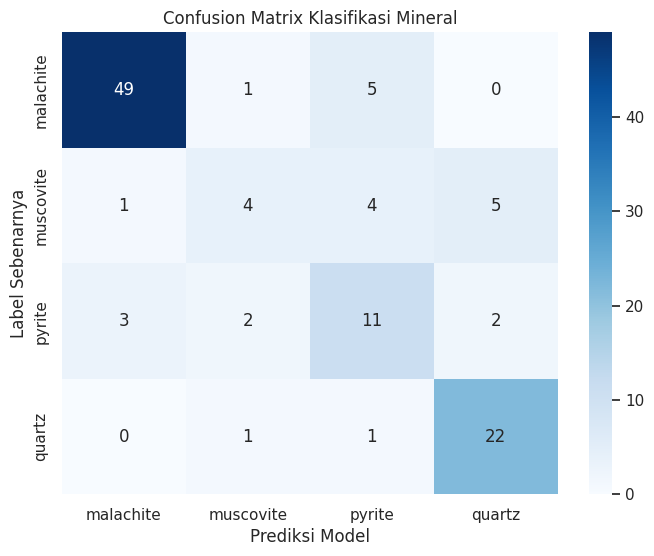

In [28]:
# 5. Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix Klasifikasi Mineral')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

# *9. Decision Boundary*

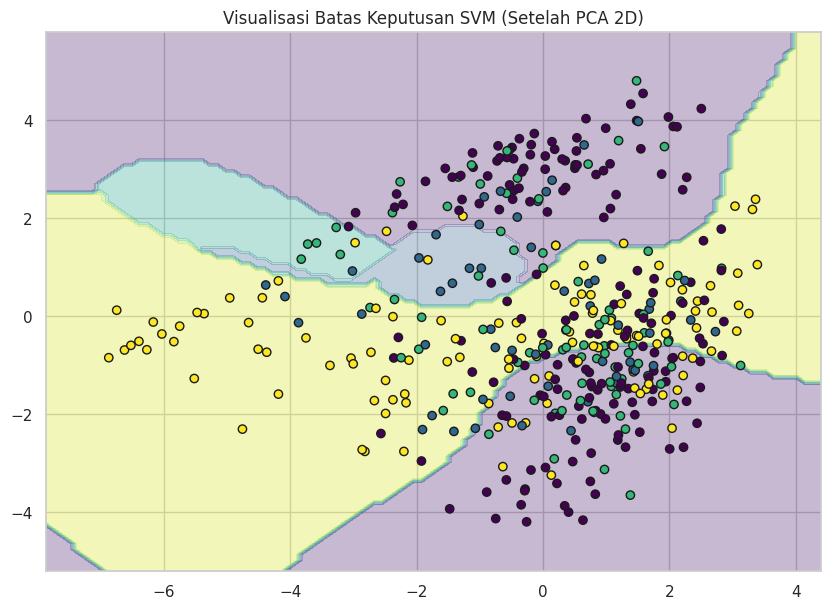

In [29]:
from sklearn.decomposition import PCA
from sklearn.inspection import DecisionBoundaryDisplay

# 1. Perkecil dimensi jadi 2D untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 2. Latih ulang model SVM sederhana pada data 2D
svm_2d = SVC(kernel='rbf', C=10)
svm_2d.fit(X_pca, y_train)

# 3. Plot Batas Keputusan
plt.figure(figsize=(10, 7))
DecisionBoundaryDisplay.from_estimator(
    svm_2d, X_pca, response_method="predict",
    cmap='viridis', alpha=0.3, ax=plt.gca()
)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, edgecolors='k', cmap='viridis')
plt.title("Visualisasi Batas Keputusan SVM (Setelah PCA 2D)")
plt.show()

# *10. Learning Curves*

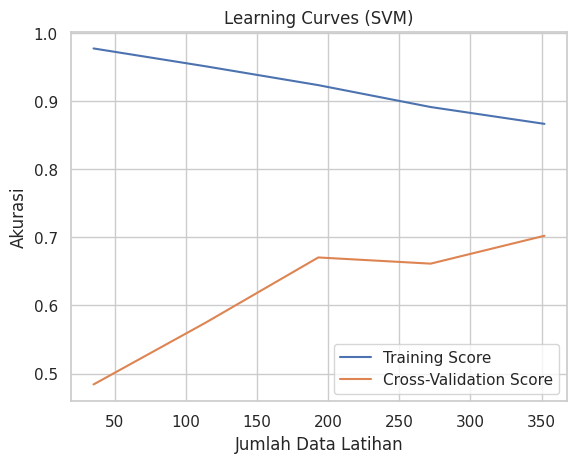

In [30]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    SVC(kernel='rbf', C=10), X_train_scaled, y_train, cv=5)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Cross-Validation Score')
plt.title("Learning Curves (SVM)")
plt.xlabel("Jumlah Data Latihan")
plt.ylabel("Akurasi")
plt.legend()
plt.show()

# *11. Clustering View*

In [31]:
import plotly.express as px

# Gunakan data yang sudah di-PCA tadi
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Mineral'] = le.inverse_transform(y_train)

fig = px.scatter(df_pca, x='PC1', y='PC2', color='Mineral',
                 title='Proyeksi Fitur Mineral dalam 2D (PCA)')
# Use 'colab' renderer to display the plot directly in the Colab output
fig.show('colab')

# *11. Classification Report Heatmap*

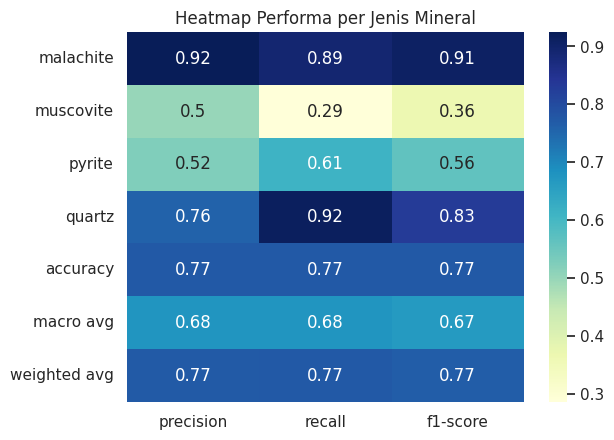

In [32]:
import pandas as pd

# Ambil laporan dalam bentuk dictionary
report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='YlGnBu')
plt.title("Heatmap Performa per Jenis Mineral")
plt.show()